In [1]:
import glob
import os
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
from matplotlib.animation import FuncAnimation
import math

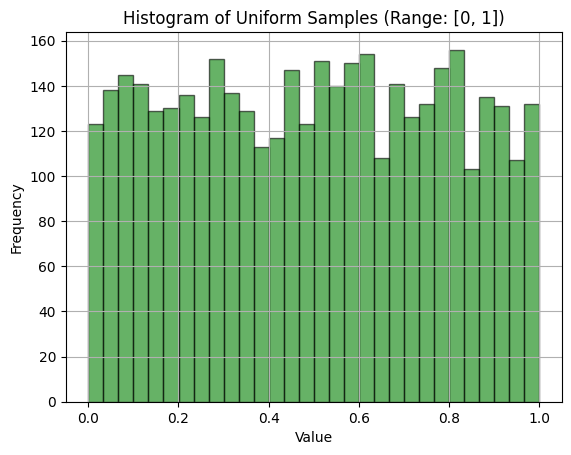

In [2]:
batch_size = 4000
# Generate sample points from a Uniform distribution (range: [low, high])
uniform_samples = np.random.uniform(low=0, high=1, size=batch_size).astype(np.float32)
uniform_samples = torch.tensor(uniform_samples).numpy()

# Plot Histogram
plt.hist(uniform_samples, bins=30, alpha=0.6, color='green', edgecolor='black')
plt.title('Histogram of Uniform Samples (Range: [0, 1])')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

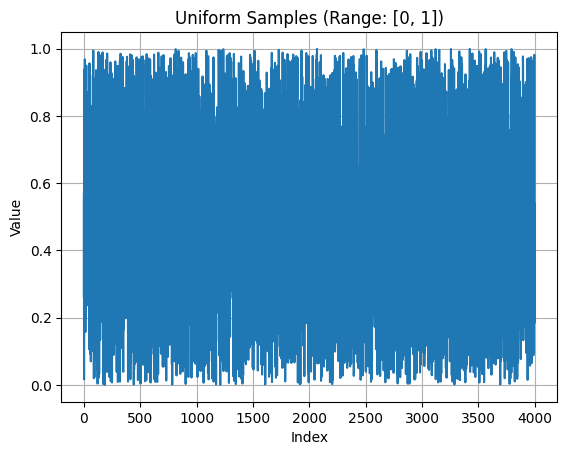

In [3]:
plt.plot(uniform_samples)
plt.title('Uniform Samples (Range: [0, 1])')
plt.xlabel('Index')
plt.ylabel('Value')
plt.grid(True)
plt.show()

Text(0.5, 0, 'Value')

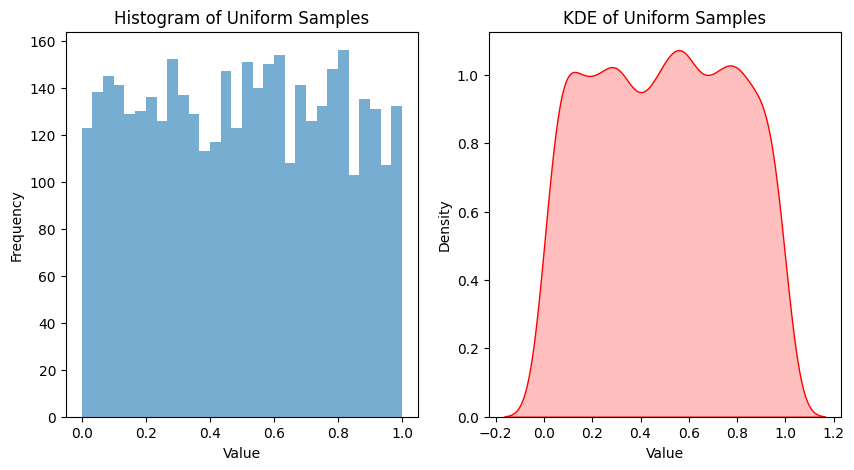

In [4]:
# Plot Histogram
plt.figure(figsize=(10, 5))

# Subplot 1: Histogram
plt.subplot(1, 2, 1)
plt.hist(uniform_samples, bins=30, alpha=0.6)
plt.title('Histogram of Uniform Samples')
plt.xlabel('Value')
plt.ylabel('Frequency')

# Subplot 2: Kernel Density Estimate (KDE)
plt.subplot(1, 2, 2)
sns.kdeplot(uniform_samples, color='red', fill=True)
plt.title('KDE of Uniform Samples')
plt.xlabel('Value')

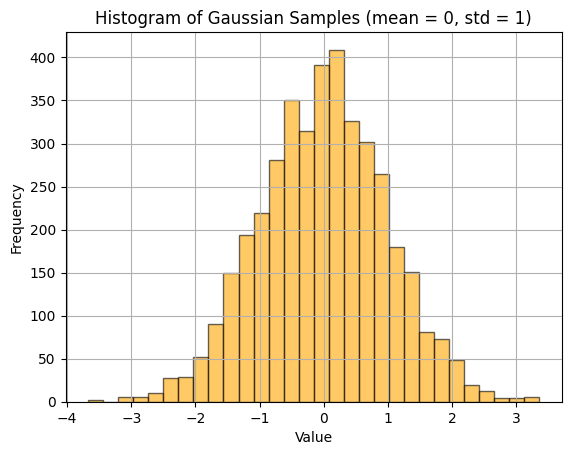

In [5]:
# Step 2: Generate 400 sample points from a Gaussian distribution (mean=0, std=1)
# gaussian_samples = np.random.normal(loc=0, scale=1, size=400).astype(np.float32)
gaussian_samples = norm.ppf(uniform_samples)
gaussian_samples = torch.tensor(gaussian_samples).numpy()

# Plot Histogram
plt.hist(gaussian_samples, bins=30, alpha=0.6, color='orange', edgecolor='black')
plt.title('Histogram of Gaussian Samples (mean = 0, std = 1)')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

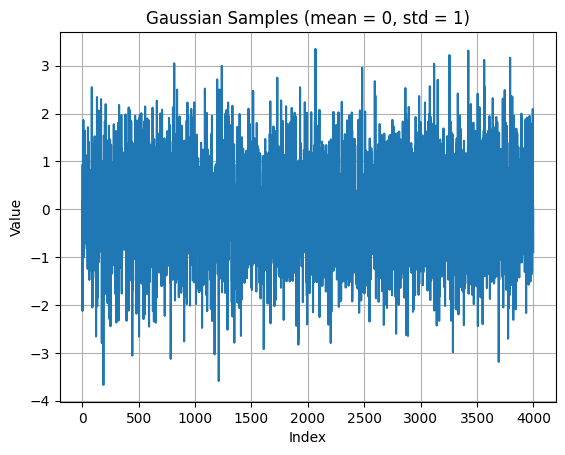

In [6]:
plt.plot(gaussian_samples)
plt.title('Gaussian Samples (mean = 0, std = 1)')
plt.xlabel('Index')
plt.ylabel('Value')
plt.grid(True)
plt.show()

Text(0.5, 0, 'Value')

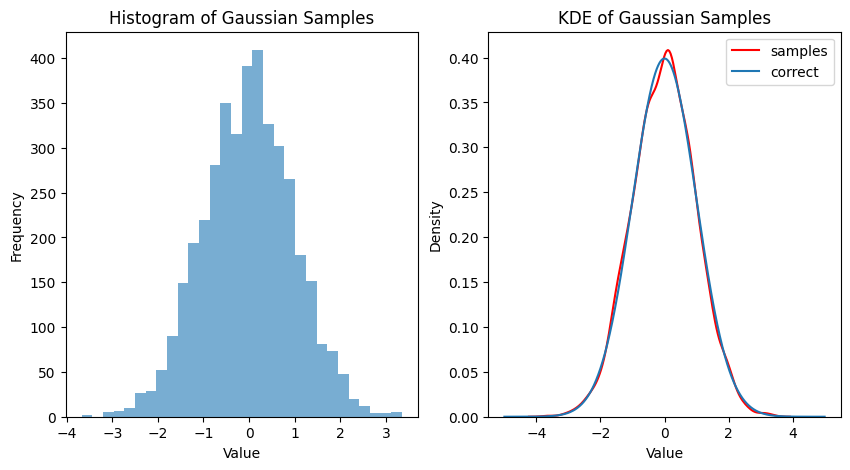

In [7]:
# Plot Histogram
plt.figure(figsize=(10, 5))

# Subplot 1: Histogram
plt.subplot(1, 2, 1)
plt.hist(gaussian_samples, bins=30, alpha=0.6)
plt.title('Histogram of Gaussian Samples')
plt.xlabel('Value')
plt.ylabel('Frequency')


# Subplot 2: Kernel Density Estimate (KDE)
plt.subplot(1, 2, 2)
sns.kdeplot(gaussian_samples, color='red',label='samples')
# Mean = 0, SD = 1.
x_axis = np.arange(-5, 5, 0.0005)
plt.plot(x_axis, norm.pdf(x_axis,0,1), label = 'correct')
plt.legend()
plt.title('KDE of Gaussian Samples')
plt.xlabel('Value')

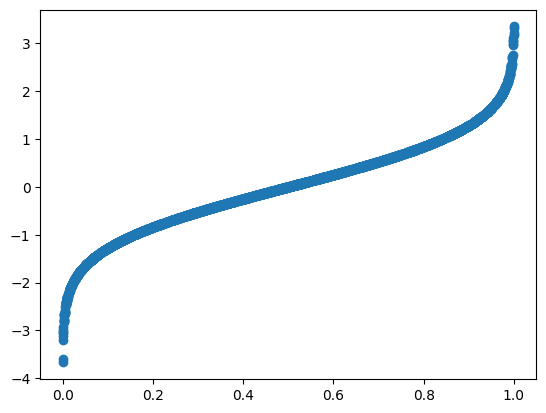

In [8]:
plt.scatter(uniform_samples, gaussian_samples)

In [9]:
uniform_samples = torch.tensor(uniform_samples).unsqueeze(1)
gaussian_samples = torch.tensor(gaussian_samples).unsqueeze(1)

In [10]:
class FNN(nn.Module):
    def __init__(self):
        super(FNN, self).__init__()
        self.fc1 = nn.Linear(1, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, 64)
        self.fc4 = nn.Linear(64, 64)
        self.fc5 = nn.Linear(64, 64)
        self.fc6 = nn.Linear(64, 1)
        self.tanh = nn.Tanh()

    def forward(self, x):
        x = self.tanh(self.fc1(x))
        x = self.tanh(self.fc2(x))
        x = self.tanh(self.fc3(x))
        x = self.tanh(self.fc4(x))
        x = self.tanh(self.fc5(x))
        return self.fc6(x)

In [11]:
# Function to compute moments (mean, variance, skewness, kurtosis, and 5th moment)
def compute_moments(samples):
    mean = torch.mean(samples)
    variance = torch.var(samples, unbiased=False)  # Population variance
    skewness = torch.mean(((samples - mean) ** 3)) / (variance ** 1.5)
    kurtosis = torch.mean(((samples - mean) ** 4)) / (variance ** 2) - 3
    fifth_moment = torch.mean((samples - mean) ** 5)
    return mean, variance, skewness, kurtosis, fifth_moment

In [12]:
def compute_mean(samples):
    mean = torch.mean(samples)
    return mean

In [13]:
def compute_variance(samples):
    variance = torch.var(samples, unbiased=False)
    return variance

In [14]:
# Initialize the neural network
model = FNN()

In [15]:
# Define optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Initialize lists to store each moment loss over epochs
mean_loss_list = []
variance_loss_list = []
total_loss_list = []
epoch_list = []

# Training loop
num_epochs = 10000
save_interval = 10  # Save model every 10 iterations

for epoch in range(num_epochs):
    uni_input = np.random.uniform(low=0, high=1, size=batch_size).astype(np.float32)
    uni_input = torch.tensor(uniform_samples).unsqueeze(1)
    # Forward pass
    outputs = model(uni_input)
    
    # Compute individual moment losses
    mean_loss = torch.abs(compute_mean(outputs) - 0) # mean of standard normal distribution is 0
    variance_loss = torch.abs(compute_variance(outputs) - 1) # variance of standard normal distribution is 1


    # Total loss with weighted moments
    total_loss = mean_loss + 2*variance_loss

    # Backward pass and optimization
    optimizer.zero_grad()
    total_loss.backward()
    optimizer.step()
    
    # Store each moment loss and epoch number
    mean_loss_list.append(mean_loss.item())
    variance_loss_list.append(variance_loss.item())
    total_loss_list.append(total_loss.item())
    epoch_list.append(epoch + 1)
    
    print(f'Epoch [{epoch+1}/{num_epochs}], Mean Loss: {mean_loss.item():.4f}, '
          f'Variance Loss: {variance_loss.item():.4f}, mean: {compute_mean(outputs):.4f}, variance: {compute_variance(outputs):.4f}')
    
    # Save model every 10 iterations
    if (epoch + 1) % save_interval == 0:
        torch.save(model.state_dict(), f"model_epoch_{epoch+1}.pt")
        print(f"Model saved at epoch {epoch+1}")
        
    # Early stopping condition
    if (mean_loss <= 0.0001 and variance_loss <= 0.0001):
        print(f"Early stopping at epoch {epoch + 1}")
        torch.save(model.state_dict(), f"model_epoch_{epoch+1}.pt")
        break

/tmp/ipykernel_653153/586174862.py:16: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  uni_input = torch.tensor(uniform_samples).unsqueeze(1)


Epoch [1/10000], Mean Loss: 0.0928, Variance Loss: 0.9999, mean: 0.0928, variance: 0.0001
Epoch [2/10000], Mean Loss: 0.0077, Variance Loss: 0.9999, mean: 0.0077, variance: 0.0001
Epoch [3/10000], Mean Loss: 0.0808, Variance Loss: 0.9998, mean: -0.0808, variance: 0.0002
Epoch [4/10000], Mean Loss: 0.0944, Variance Loss: 0.9998, mean: -0.0944, variance: 0.0002
Epoch [5/10000], Mean Loss: 0.0754, Variance Loss: 0.9998, mean: -0.0754, variance: 0.0002
Epoch [6/10000], Mean Loss: 0.0424, Variance Loss: 0.9999, mean: -0.0424, variance: 0.0001
Epoch [7/10000], Mean Loss: 0.0040, Variance Loss: 0.9999, mean: -0.0040, variance: 0.0001
Epoch [8/10000], Mean Loss: 0.0357, Variance Loss: 1.0000, mean: 0.0357, variance: 0.0000
Epoch [9/10000], Mean Loss: 0.0556, Variance Loss: 1.0000, mean: 0.0556, variance: 0.0000
Epoch [10/10000], Mean Loss: 0.0625, Variance Loss: 1.0000, mean: 0.0625, variance: 0.0000
Model saved at epoch 10
Epoch [11/10000], Mean Loss: 0.0606, Variance Loss: 1.0000, mean: 0.06

Epoch [93/10000], Mean Loss: 0.0005, Variance Loss: 0.9999, mean: -0.0005, variance: 0.0001
Epoch [94/10000], Mean Loss: 0.0014, Variance Loss: 0.9999, mean: -0.0014, variance: 0.0001
Epoch [95/10000], Mean Loss: 0.0005, Variance Loss: 0.9999, mean: 0.0005, variance: 0.0001
Epoch [96/10000], Mean Loss: 0.0006, Variance Loss: 0.9999, mean: -0.0006, variance: 0.0001
Epoch [97/10000], Mean Loss: 0.0012, Variance Loss: 0.9999, mean: 0.0012, variance: 0.0001
Epoch [98/10000], Mean Loss: 0.0001, Variance Loss: 0.9999, mean: 0.0001, variance: 0.0001
Epoch [99/10000], Mean Loss: 0.0035, Variance Loss: 0.9999, mean: -0.0035, variance: 0.0001
Epoch [100/10000], Mean Loss: 0.0041, Variance Loss: 0.9999, mean: -0.0041, variance: 0.0001
Model saved at epoch 100
Epoch [101/10000], Mean Loss: 0.0019, Variance Loss: 0.9999, mean: -0.0019, variance: 0.0001
Epoch [102/10000], Mean Loss: 0.0027, Variance Loss: 0.9999, mean: 0.0027, variance: 0.0001
Epoch [103/10000], Mean Loss: 0.0043, Variance Loss: 0.9

Epoch [189/10000], Mean Loss: 0.0044, Variance Loss: 0.9999, mean: 0.0044, variance: 0.0001
Epoch [190/10000], Mean Loss: 0.0006, Variance Loss: 0.9999, mean: 0.0006, variance: 0.0001
Model saved at epoch 190
Epoch [191/10000], Mean Loss: 0.0053, Variance Loss: 0.9999, mean: -0.0053, variance: 0.0001
Epoch [192/10000], Mean Loss: 0.0082, Variance Loss: 0.9999, mean: -0.0082, variance: 0.0001
Epoch [193/10000], Mean Loss: 0.0084, Variance Loss: 0.9999, mean: -0.0084, variance: 0.0001
Epoch [194/10000], Mean Loss: 0.0062, Variance Loss: 0.9999, mean: -0.0062, variance: 0.0001
Epoch [195/10000], Mean Loss: 0.0020, Variance Loss: 0.9999, mean: -0.0020, variance: 0.0001
Epoch [196/10000], Mean Loss: 0.0040, Variance Loss: 0.9999, mean: 0.0040, variance: 0.0001
Epoch [197/10000], Mean Loss: 0.0072, Variance Loss: 0.9999, mean: 0.0072, variance: 0.0001
Epoch [198/10000], Mean Loss: 0.0078, Variance Loss: 0.9999, mean: 0.0078, variance: 0.0001
Epoch [199/10000], Mean Loss: 0.0063, Variance Los

Epoch [283/10000], Mean Loss: 0.0001, Variance Loss: 0.9994, mean: -0.0001, variance: 0.0006
Epoch [284/10000], Mean Loss: 0.0029, Variance Loss: 0.9994, mean: 0.0029, variance: 0.0006
Epoch [285/10000], Mean Loss: 0.0029, Variance Loss: 0.9993, mean: 0.0029, variance: 0.0007
Epoch [286/10000], Mean Loss: 0.0001, Variance Loss: 0.9993, mean: -0.0001, variance: 0.0007
Epoch [287/10000], Mean Loss: 0.0002, Variance Loss: 0.9992, mean: 0.0002, variance: 0.0008
Epoch [288/10000], Mean Loss: 0.0028, Variance Loss: 0.9991, mean: -0.0028, variance: 0.0009
Epoch [289/10000], Mean Loss: 0.0023, Variance Loss: 0.9990, mean: -0.0023, variance: 0.0010
Epoch [290/10000], Mean Loss: 0.0017, Variance Loss: 0.9989, mean: 0.0017, variance: 0.0011
Model saved at epoch 290
Epoch [291/10000], Mean Loss: 0.0017, Variance Loss: 0.9988, mean: 0.0017, variance: 0.0012
Epoch [292/10000], Mean Loss: 0.0022, Variance Loss: 0.9986, mean: -0.0022, variance: 0.0014
Epoch [293/10000], Mean Loss: 0.0018, Variance Los

...

Epoch [7510/10000], Mean Loss: 0.0022, Variance Loss: 0.0089, mean: -0.0022, variance: 1.0089
Model saved at epoch 7510
Epoch [7511/10000], Mean Loss: 0.0004, Variance Loss: 0.0028, mean: -0.0004, variance: 1.0028
Epoch [7512/10000], Mean Loss: 0.0043, Variance Loss: 0.0077, mean: 0.0043, variance: 0.9923
Epoch [7513/10000], Mean Loss: 0.0054, Variance Loss: 0.0122, mean: 0.0054, variance: 0.9878
Epoch [7514/10000], Mean Loss: 0.0032, Variance Loss: 0.0111, mean: 0.0032, variance: 0.9889
Epoch [7515/10000], Mean Loss: 0.0019, Variance Loss: 0.0053, mean: -0.0019, variance: 0.9947
Epoch [7516/10000], Mean Loss: 0.0029, Variance Loss: 0.0049, mean: -0.0029, variance: 1.0049
Epoch [7517/10000], Mean Loss: 0.0006, Variance Loss: 0.0091, mean: -0.0006, variance: 1.0091
Epoch [7518/10000], Mean Loss: 0.0046, Variance Loss: 0.0078, mean: 0.0046, variance: 1.0078
Epoch [7519/10000], Mean Loss: 0.0056, Variance Loss: 0.0012, mean: 0.0056, variance: 1.0012
Epoch [7520/10000], Mean Loss: 0.0029, 

Epoch [7603/10000], Mean Loss: 0.0060, Variance Loss: 0.0060, mean: 0.0060, variance: 1.0060
Epoch [7604/10000], Mean Loss: 0.0033, Variance Loss: 0.0031, mean: 0.0033, variance: 1.0031
Epoch [7605/10000], Mean Loss: 0.0027, Variance Loss: 0.0046, mean: -0.0027, variance: 0.9954
Epoch [7606/10000], Mean Loss: 0.0045, Variance Loss: 0.0065, mean: -0.0045, variance: 0.9935
Epoch [7607/10000], Mean Loss: 0.0025, Variance Loss: 0.0032, mean: -0.0025, variance: 0.9968
Epoch [7608/10000], Mean Loss: 0.0031, Variance Loss: 0.0048, mean: 0.0031, variance: 1.0048
Epoch [7609/10000], Mean Loss: 0.0044, Variance Loss: 0.0069, mean: 0.0044, variance: 1.0069
Epoch [7610/10000], Mean Loss: 0.0020, Variance Loss: 0.0038, mean: 0.0020, variance: 1.0038
Model saved at epoch 7610
Epoch [7611/10000], Mean Loss: 0.0038, Variance Loss: 0.0041, mean: -0.0038, variance: 0.9959
Epoch [7612/10000], Mean Loss: 0.0054, Variance Loss: 0.0062, mean: -0.0054, variance: 0.9938
Epoch [7613/10000], Mean Loss: 0.0032, 

Epoch [7700/10000], Mean Loss: 0.0037, Variance Loss: 0.0035, mean: -0.0037, variance: 0.9965
Model saved at epoch 7700
Epoch [7701/10000], Mean Loss: 0.0016, Variance Loss: 0.0025, mean: -0.0016, variance: 0.9975
Epoch [7702/10000], Mean Loss: 0.0039, Variance Loss: 0.0035, mean: 0.0039, variance: 1.0035
Epoch [7703/10000], Mean Loss: 0.0053, Variance Loss: 0.0037, mean: 0.0053, variance: 1.0037
Epoch [7704/10000], Mean Loss: 0.0029, Variance Loss: 0.0010, mean: 0.0029, variance: 0.9990
Epoch [7705/10000], Mean Loss: 0.0023, Variance Loss: 0.0006, mean: -0.0023, variance: 0.9994
Epoch [7706/10000], Mean Loss: 0.0033, Variance Loss: 0.0048, mean: -0.0033, variance: 1.0048
Epoch [7707/10000], Mean Loss: 0.0013, Variance Loss: 0.0049, mean: -0.0013, variance: 1.0049
Epoch [7708/10000], Mean Loss: 0.0037, Variance Loss: 0.0003, mean: 0.0037, variance: 1.0003
Epoch [7709/10000], Mean Loss: 0.0045, Variance Loss: 0.0089, mean: 0.0045, variance: 0.9911
Epoch [7710/10000], Mean Loss: 0.0021, 

Epoch [7795/10000], Mean Loss: 0.0003, Variance Loss: 0.0137, mean: 0.0003, variance: 1.0137
Epoch [7796/10000], Mean Loss: 0.0020, Variance Loss: 0.0196, mean: -0.0020, variance: 1.0196
Epoch [7797/10000], Mean Loss: 0.0005, Variance Loss: 0.0137, mean: -0.0005, variance: 1.0137
Epoch [7798/10000], Mean Loss: 0.0041, Variance Loss: 0.0006, mean: 0.0041, variance: 0.9994
Epoch [7799/10000], Mean Loss: 0.0049, Variance Loss: 0.0047, mean: 0.0049, variance: 0.9953
Epoch [7800/10000], Mean Loss: 0.0023, Variance Loss: 0.0012, mean: 0.0023, variance: 0.9988
Model saved at epoch 7800
Epoch [7801/10000], Mean Loss: 0.0032, Variance Loss: 0.0092, mean: -0.0032, variance: 1.0092
Epoch [7802/10000], Mean Loss: 0.0050, Variance Loss: 0.0111, mean: -0.0050, variance: 1.0111
Epoch [7803/10000], Mean Loss: 0.0035, Variance Loss: 0.0060, mean: -0.0035, variance: 1.0060
Epoch [7804/10000], Mean Loss: 0.0010, Variance Loss: 0.0043, mean: 0.0010, variance: 0.9957
Epoch [7805/10000], Mean Loss: 0.0019, 

Epoch [7889/10000], Mean Loss: 0.0033, Variance Loss: 0.0015, mean: 0.0033, variance: 1.0015
Epoch [7890/10000], Mean Loss: 0.0055, Variance Loss: 0.0081, mean: 0.0055, variance: 0.9919
Model saved at epoch 7890
Epoch [7891/10000], Mean Loss: 0.0045, Variance Loss: 0.0116, mean: 0.0045, variance: 0.9884
Epoch [7892/10000], Mean Loss: 0.0005, Variance Loss: 0.0101, mean: 0.0005, variance: 0.9899
Epoch [7893/10000], Mean Loss: 0.0060, Variance Loss: 0.0042, mean: -0.0060, variance: 0.9958
Epoch [7894/10000], Mean Loss: 0.0082, Variance Loss: 0.0061, mean: -0.0082, variance: 1.0061
Epoch [7895/10000], Mean Loss: 0.0074, Variance Loss: 0.0108, mean: -0.0074, variance: 1.0108
Epoch [7896/10000], Mean Loss: 0.0037, Variance Loss: 0.0103, mean: -0.0037, variance: 1.0103
Epoch [7897/10000], Mean Loss: 0.0026, Variance Loss: 0.0051, mean: 0.0026, variance: 1.0051
Epoch [7898/10000], Mean Loss: 0.0046, Variance Loss: 0.0045, mean: 0.0046, variance: 0.9955
Epoch [7899/10000], Mean Loss: 0.0035, V

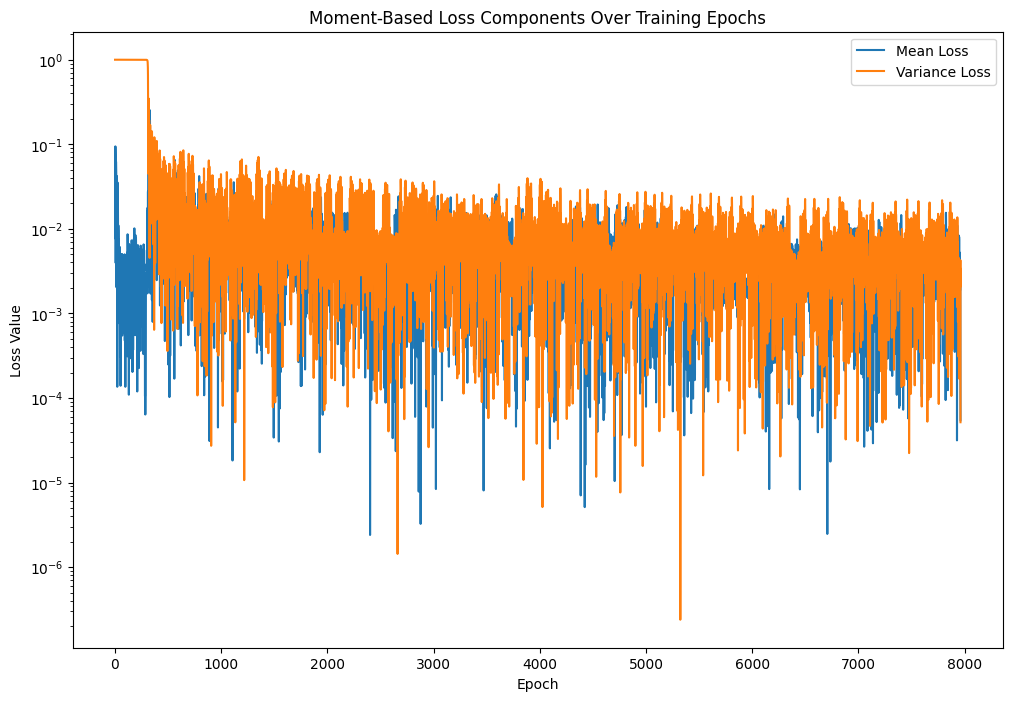

In [16]:
# Plot each loss component
plt.figure(figsize=(12, 8))
plt.yscale('log')
plt.plot(epoch_list, mean_loss_list, label="Mean Loss")
plt.plot(epoch_list, variance_loss_list, label="Variance Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss Value")
plt.title("Moment-Based Loss Components Over Training Epochs")
plt.legend()
plt.show()

Text(0, 0.5, '$l_1$')

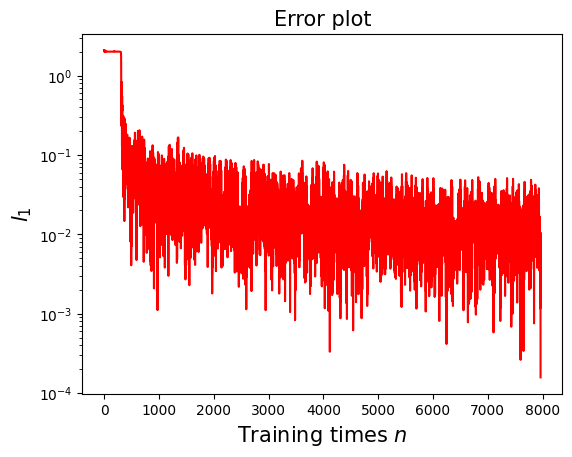

In [17]:
fig = plt.figure(1)
ax = fig.add_axes([0.15, 0.15, 0.75, 0.75])
plt.title("Error plot",fontsize=15) 
plt.yscale('log')
plt.plot(epoch_list, total_loss_list,'r',label='Training error')
plt.xlabel(r'Training times $n$',fontsize=15)
plt.ylabel(r'$l_1$',fontsize=15)

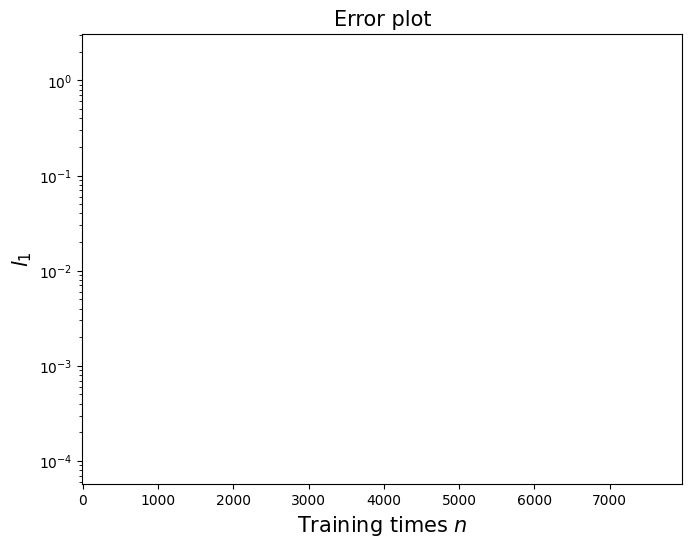

In [18]:
# Initialize figure
fig = plt.figure(1, figsize=(8, 6))
ax = fig.add_axes([0.15, 0.15, 0.75, 0.75])
ax.set_title("Error plot", fontsize=15)
ax.set_xlabel(r'Training times $n$', fontsize=15)
ax.set_ylabel(r'$l_1$', fontsize=15)
ax.set_yscale('log')  # Use logarithmic scale for better visualization
ax.set_xlim(-5, epoch_list[-1]+5)  # Initial x-axis limit
ax.set_ylim(min(total_loss_list)-0.0001, max(total_loss_list)+1)  # Set y-axis limit

# Initialize line plot object (empty initially)
line, = ax.plot([], [], 'r', label='Training error')

# Function to update the plot in the animation
def update_plot(frame):
    # Show 10 more points at each frame
    end_index = (frame + 1) * 10
    epoch_data = epoch_list[:end_index]
    loss_data = total_loss_list[:end_index]
    
    # Update the line data
    line.set_data(epoch_data, loss_data)
    
    # Update the title to reflect the current epoch range
    ax.set_title(f"Error plot from Epoch 1 to Epoch {epoch_data[-1]}", fontsize=15)
    
    return line,

# Number of frames to show (every 10 epochs)
num_frames = len(epoch_list) // 10  # Adjust for how many epochs you have
if len(epoch_list) % 10 != 0:
    num_frames += 1

# Create the animation
anim = FuncAnimation(fig, update_plot, frames=num_frames, interval=500, repeat=False)

# Show the animation
plt.show()

# Optionally save the animation as a GIF
anim.save("error_plot_animation.gif", writer="pillow", fps=2)


In [19]:
from matplotlib.animation import FuncAnimation

# Set the input for testing the transformation
input_test = torch.tensor(np.linspace(0, 1, batch_size).astype(np.float32)).unsqueeze(1)
uniform_samples_np = uniform_samples.numpy()
gaussian_samples_np = gaussian_samples.numpy()

In [20]:
# Function to load model and transform samples
def load_and_transform(model, model_path, input_test):
    model.load_state_dict(torch.load(model_path))
    model.eval()  # Set model to evaluation mode
    with torch.no_grad():
        transformed_samples = model(input_test)
    return transformed_samples.numpy()

In [21]:
# Get list of saved models sorted by creation time
model_files = sorted(glob.glob("model_epoch_*.pt"), key=os.path.getmtime)

if not model_files:
    print("No model files found.")
else:
    # Collect transformed samples for each saved model
    transformed_samples_list = [load_and_transform(model, path, input_test) for path in model_files]

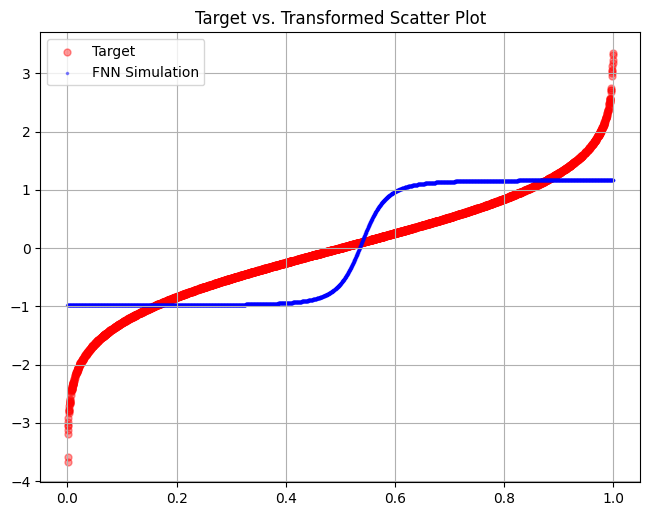

In [22]:
# Set up the figure with two subplots
fig = plt.figure(1, figsize=(8, 6))
ax = fig.add_axes([0.15, 0.15, 0.75, 0.75])

# Scatter plot
scatter_target = ax.scatter(uniform_samples_np, gaussian_samples_np, c='r', s=25, alpha=0.4, marker='o', label='Target')
scatter_sim = ax.scatter(1-input_test.numpy(), transformed_samples_list[-1], c='b', s=10, alpha=0.4, marker='.', label='FNN Simulation')
ax.legend()
ax.set_title("Target vs. Transformed Scatter Plot")
ax.grid(True)


In [23]:
# Animation function
def animate(i):
    # Update scatter plot for FNN simulation
    epoch = int(model_files[i].split('_')[-1].split('.')[0])
    scatter_sim.set_offsets(np.c_[1-input_test.numpy(), transformed_samples_list[i]])
    ax.set_title(f"Scatter Plot at Epoch {epoch}")

In [24]:
# Create the animation
anim = FuncAnimation(fig, animate, frames=len(transformed_samples_list), interval=500)
%matplotlib inline
# Display the animation
plt.show()
# Save animation
anim.save("training_animation.gif", writer="pillow", fps=2)

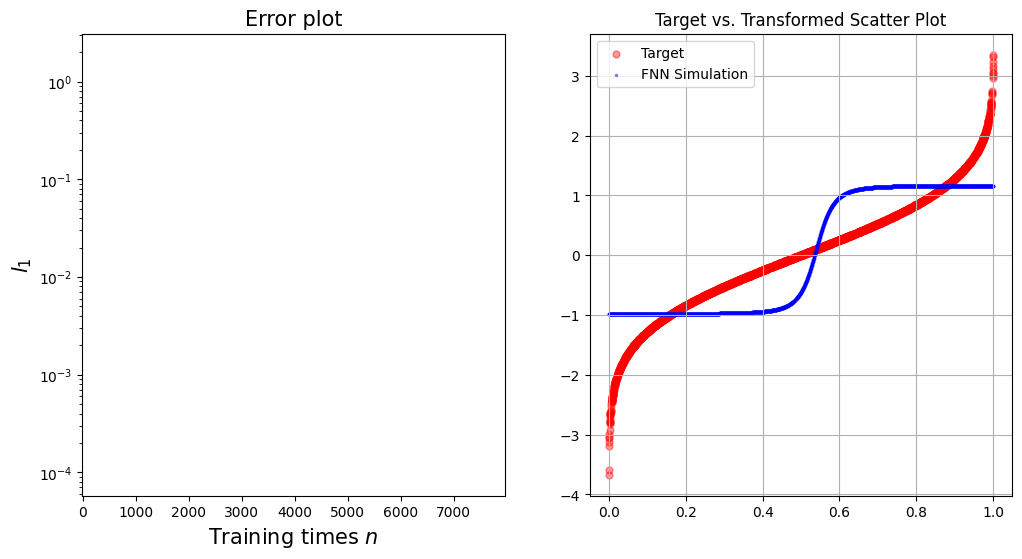

In [25]:
# Set up the figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Total loss plot (ax1)
ax1.set_title("Error plot", fontsize=15)
ax1.set_xlabel(r'Training times $n$', fontsize=15)
ax1.set_ylabel(r'$l_1$', fontsize=15)
ax1.set_yscale('log')  # Use logarithmic scale for better visualization
ax1.set_xlim(-5, epoch_list[-1]+5)  # Initial x-axis limit
ax1.set_ylim(min(total_loss_list)-0.0001, max(total_loss_list)+1)  # Set y-axis limit
line, = ax1.plot([], [], 'r', label='Training error')

# Scatter plot (ax2)
scatter_target = ax2.scatter(uniform_samples_np, gaussian_samples_np, c='r', s=25, alpha=0.4, marker='o', label='Target')
scatter_sim = ax2.scatter(1-input_test.numpy(), transformed_samples_list[-1], c='b', s=10, alpha=0.4, marker='.', label='FNN Simulation')
ax2.legend()
ax2.set_title("Target vs. Transformed Scatter Plot")
ax2.grid(True)

# Function to update both the total loss plot and scatter plot
def update_plot(frame):
    # Update total loss plot (ax1)
    end_index = (frame + 1) * 10
    epoch_data = epoch_list[:end_index]
    loss_data = total_loss_list[:end_index]
    line.set_data(epoch_data, loss_data)
    
    # Update scatter plot (ax2) for FNN simulation
    scatter_sim.set_offsets(np.c_[1-input_test.numpy(), transformed_samples_list[frame]])
    
    # Update titles
    ax1.set_title(f"Error plot from Epoch 1 to Epoch {epoch_data[-1]}", fontsize=15)
    ax2.set_title(f"Scatter Plot at Epoch {frame * 10}", fontsize=15)
    
    return line, scatter_sim  # Return the updated plot elements

# Number of frames to show (every 10 epochs)
num_frames = len(epoch_list) // 10  # Adjust for how many epochs you have
if len(epoch_list) % 10 != 0:
    num_frames += 1

# Create the combined animation
anim = FuncAnimation(fig, update_plot, frames=num_frames, interval=500, repeat=False)

# Show the animation
plt.show()

# Optionally, save the animation as a GIF
anim.save("combined_training_animation.gif", writer="pillow", fps=10)

In [26]:
# Test the transformation from final model
with torch.no_grad():
    transformed_samples = model(input_test)


# Convert tensors to numpy for visualization
transformed_samples_np = transformed_samples.numpy()

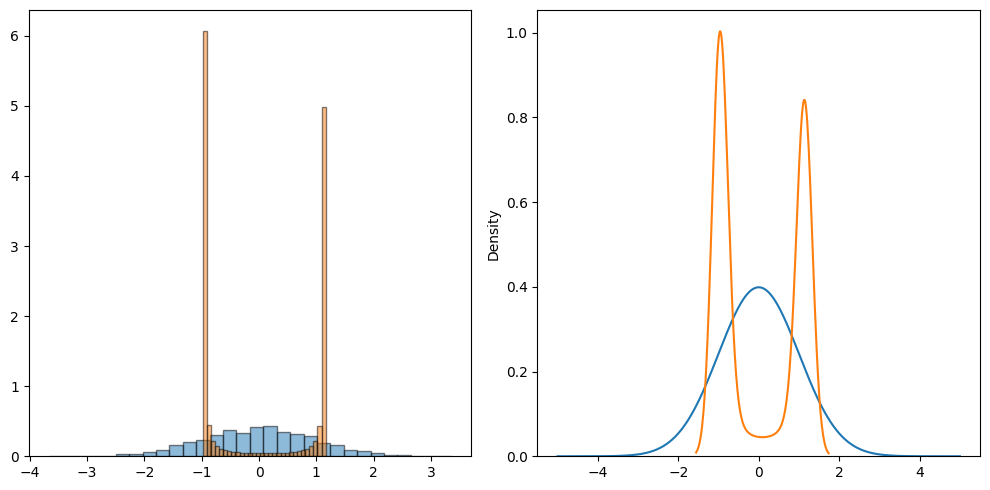

In [27]:
# Step 7: Plot the original and transformed distributions
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.hist(gaussian_samples_np, bins=30, alpha=0.5, density=True, edgecolor='black')
plt.hist(transformed_samples_np, bins=30, alpha=0.5, density=True, edgecolor='black')
# plt.title('Gaussian vs Transformed Distribution')
# plt.legend()

plt.subplot(1, 2, 2)
# Gaussian distribution with Mean = 0, SD = 1.
x_axis = np.arange(-5, 5, 0.0005)
plt.plot(x_axis, norm.pdf(x_axis,0,1))
sns.kdeplot(transformed_samples.cpu().reshape(batch_size))
# plt.title('Gaussian vs Transformed Distribution')

plt.tight_layout()
plt.show()

Text(0, 0.5, 'Frequency')

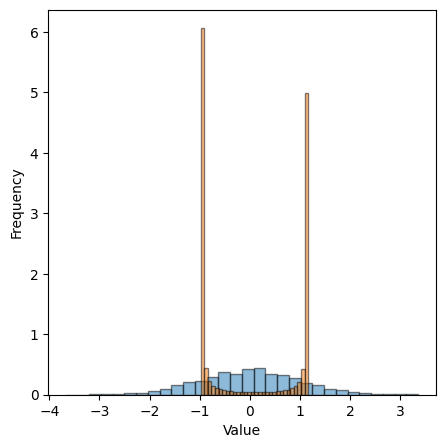

In [28]:
plt.figure(figsize=(5, 5))
plt.hist(gaussian_samples_np, bins=30, alpha=0.5, density=True, edgecolor='black')
plt.hist(transformed_samples_np, bins=30, alpha=0.5, density=True, edgecolor='black')
plt.xlabel('Value')
plt.ylabel('Frequency')
# plt.title('Gaussian vs Transformed Distribution')

Text(0.5, 0, 'Value')

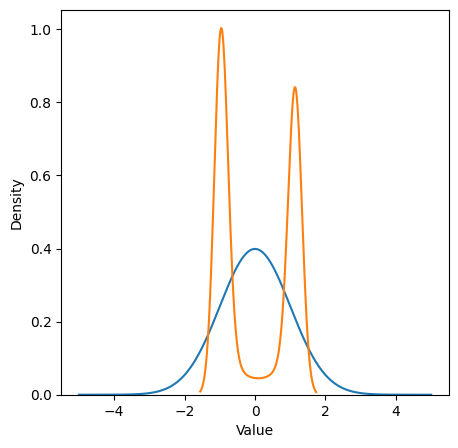

In [32]:
plt.figure(figsize=(5, 5))
# Normal distribution with Mean = 0, SD = 1.
x_axis = np.arange(-5, 5, 0.0005)
plt.plot(x_axis, norm.pdf(x_axis,0,1))
sns.kdeplot(transformed_samples.cpu().reshape(batch_size))
# plt.title('Gaussian vs Transformed Distribution')
plt.xlabel('Value')
# plt.ylim(0, 0.71)

In [30]:
# Test the transformation from final model
with torch.no_grad():
    transformed_samples1 = model(uniform_samples)


print(torch.mean(transformed_samples1))
print(compute_variance(transformed_samples1))

tensor(0.0033)
tensor(1.0086)


In [31]:
print(compute_mean(gaussian_samples))
print(compute_variance(gaussian_samples))

tensor(-0.0148, dtype=torch.float64)
tensor(0.9676, dtype=torch.float64)
